# Potato Leaf Disease Classification
### Feature-based Computer Vision Approach

Classes:
- Healthy
- Early Blight
- Late Blight

Pipeline:
1. Feature Extraction (Colour + GLCM)
2. SVM Classification
3. Evaluation & Visualization

In [1]:
import functions as f
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

## Dataset preview

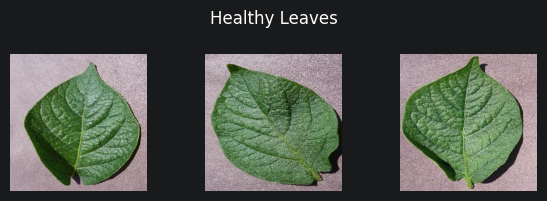

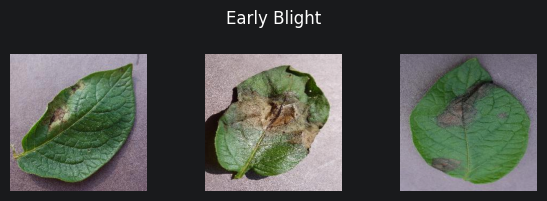

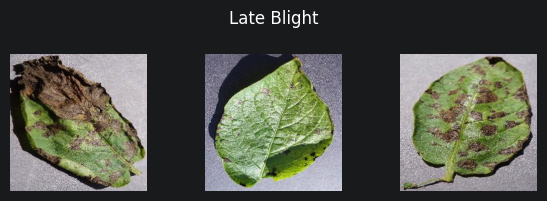

In [2]:
healthy_path = "Potato_healthy/"
early_path   = "Potato_Early_blight/"
late_path    = "Potato_Late_blight/"

healthy_paths = [os.path.join(healthy_path, f) for f in os.listdir(healthy_path)]
early_paths   = [os.path.join(early_path, f)   for f in os.listdir(early_path)]
late_paths    = [os.path.join(late_path, f)    for f in os.listdir(late_path)]



def show_samples(paths, title):
    plt.figure(figsize=(6,2))
    for i in range(3):
        img = f.LoadImage(paths[i])
        img = cv2.cvtColor(img, cv2.COLOR_HSV2RGB)
        plt.subplot(1,3,i+1)
        plt.imshow(img)
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_samples(healthy_paths, "Healthy Leaves")
show_samples(early_paths, "Early Blight")
show_samples(late_paths, "Late Blight")

## Feature Extraction Pipeline

In [3]:
"""Pathing and preparing dataset-------------------------------------------------------------------------------------"""
import os

def load_dataset(paths, label):
    X_local = []
    y_local = []

    for path in paths:
        img = f.LoadImage(path) # Load in hsv, resize
        #mask = f.segment_plant_hsv(img)

        h, w = img.shape[:2]
        mask = np.ones((h, w), dtype=np.uint8) # because functions are made for segment masks, use this instead

        feats = f.extract_features(img, mask)

        X_local.append(feats)
        y_local.append(label)

    return X_local, y_local

## Build Dataset

In [4]:
healthy_path = "Potato_healthy/"
early_path   = "Potato_Early_blight/"
late_path    = "Potato_Late_blight/"

healthy_paths = [os.path.join(healthy_path, f) for f in os.listdir(healthy_path)]
early_paths   = [os.path.join(early_path, f)   for f in os.listdir(early_path)]
late_paths    = [os.path.join(late_path, f)    for f in os.listdir(late_path)]

X, y = [], []

for paths, label in [
    (healthy_paths, 0),
    (early_paths, 1),
    (late_paths, 2)
]:
    X_part, y_part = load_dataset(paths, label)
    X.extend(X_part)
    y.extend(y_part)

X = np.array(X, dtype=np.float32)
y = np.array(y)

## Train / Validation / Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=20
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=20
)

## Feature Scaling

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

## Hyperparameter Tuning Plot

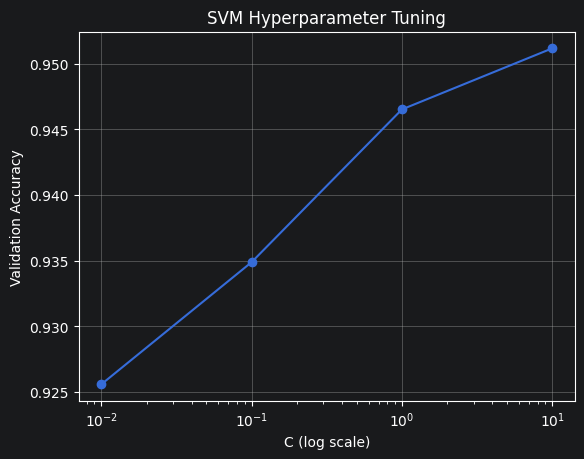

In [7]:
from sklearn.svm import LinearSVC

C_values = [0.01, 0.1, 1, 10]
scores = []

for C in C_values:
    model = LinearSVC(C=C, max_iter=5000)
    model.fit(X_train_scaled, y_train)
    score = model.score(X_val_scaled, y_val)
    scores.append(score)

plt.figure()
plt.plot(C_values, scores, marker='o')
plt.xscale('log')
plt.xlabel("C (log scale)")
plt.ylabel("Validation Accuracy")
plt.title("SVM Hyperparameter Tuning")
plt.grid(True)
plt.show()

best_C = C_values[np.argmax(scores)]

## Final Model Training

In [8]:
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.hstack([y_train, y_val])

scaler_final = StandardScaler()
X_trainval_scaled = scaler_final.fit_transform(X_trainval)
X_test_scaled_final = scaler_final.transform(X_test)

final_model = LinearSVC(C=best_C, max_iter=5000)
final_model.fit(X_trainval_scaled, y_trainval)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rando

## Final Results

In [9]:
from sklearn.metrics import accuracy_score, classification_report

test_pred = final_model.predict(X_test_scaled_final)

print("Accuracy:", accuracy_score(y_test, test_pred))
print(classification_report(y_test, test_pred))

Accuracy: 0.951276102088167
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        31
           1       0.94      0.96      0.95       200
           2       0.97      0.94      0.95       200

    accuracy                           0.95       431
   macro avg       0.95      0.95      0.95       431
weighted avg       0.95      0.95      0.95       431



## Confusion Matrix

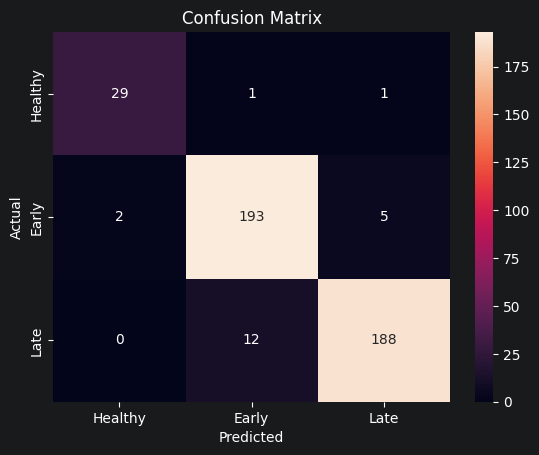

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, test_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["Healthy","Early","Late"],
            yticklabels=["Healthy","Early","Late"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Feature Importance

    # Colour features
    "H_mean", "H_std",
    "S_mean", "S_std",
    "V_mean", "V_std",
    "early_ratio", "yellow_ratio", "brown_ratio",

    # GLCM features
    "contrast",
    "homogeneity",
    "energy",
    "correlation",
    "dissimilarity",
    "ASM",
    "entropy"


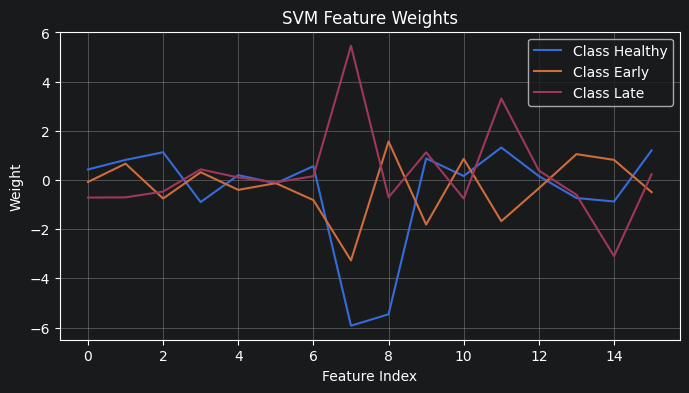

In [13]:
weights = final_model.coef_

title_label = ["Healthy", "Early", "Late"]
plt.figure(figsize=(8,4))
for i, w in enumerate(weights):
    plt.plot(w, label=f"Class {title_label[i]}")

plt.title("SVM Feature Weights")
plt.xlabel("Feature Index")
plt.ylabel("Weight")
plt.legend()
plt.grid(True)
plt.show()

## LDA Visualisation

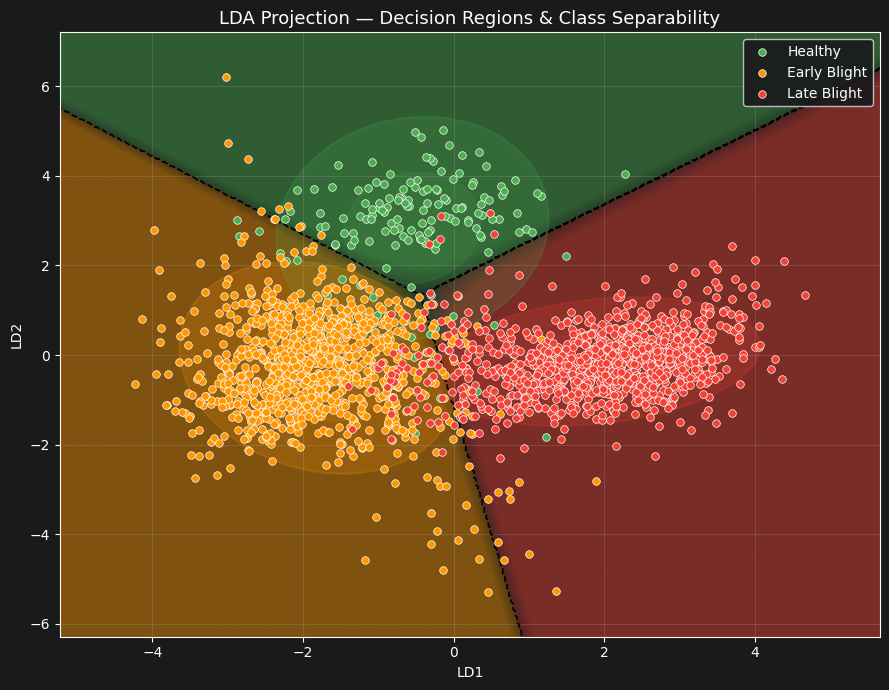

In [12]:
"""Visualization-----------------------------------------------------------------------------------------------------"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Ellipse
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

# --- LDA projection ---
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_lda, y)

# --- Meshgrid ---
margin = 1.0
x_min, x_max = X_lda[:, 0].min() - margin, X_lda[:, 0].max() + margin
y_min, y_max = X_lda[:, 1].min() - margin, X_lda[:, 1].max() + margin

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# --- Probability-based region shading ---
# proba shape: (N, 3) — one column per class
proba = clf.predict_proba(grid)
Z_pred = np.argmax(proba, axis=1)
Z_conf = np.max(proba, axis=1)   # confidence = how sure the classifier is

Z_pred = Z_pred.reshape(xx.shape)
Z_conf = Z_conf.reshape(xx.shape)

# Class colors (regions and scatter share the same palette)
CLASS_COLORS = {0: "#4CAF50", 1: "#FF9800", 2: "#F44336"}  # green, orange, red
CLASS_NAMES  = {0: "Healthy", 1: "Early Blight", 2: "Late Blight"}

# Build an RGBA image for the region background
rgba = np.zeros((*xx.shape, 4))
for label, hex_color in CLASS_COLORS.items():
    rgb = mcolors.to_rgb(hex_color)
    mask = (Z_pred == label)
    rgba[mask, 0] = rgb[0]
    rgba[mask, 1] = rgb[1]
    rgba[mask, 2] = rgb[2]

# Alpha driven by confidence: low-confidence (overlap) zones fade out
rgba[..., 3] = np.clip((Z_conf - 0.33) / 0.67, 0.05, 0.45)

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 7))

ax.imshow(
    rgba,
    origin="lower",
    extent=[x_min, x_max, y_min, y_max],
    aspect="auto",
    interpolation="bilinear"
)

# Decision boundary lines (where classifier switches prediction)
ax.contour(
    xx, yy, Z_pred,
    levels=[0.5, 1.5],
    colors="black",
    linewidths=1.2,
    linestyles="--"
)

# Covariance ellipses (1σ and 2σ) per class
def plot_cov_ellipse(ax, points, color, n_std=2.0, alpha=0.18):
    mean = points.mean(axis=0)
    cov  = np.cov(points.T)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    for std in [1.0, n_std]:
        w, h = 2 * std * np.sqrt(vals)
        ell = Ellipse(
            xy=mean, width=w, height=h, angle=angle,
            facecolor=color, alpha=alpha if std == n_std else alpha * 0.6,
            edgecolor=color, linewidth=1.5, linestyle="-"
        )
        ax.add_patch(ell)

for label, color in CLASS_COLORS.items():
    pts = X_lda[y == label]
    plot_cov_ellipse(ax, pts, color)

# Scatter points
for label, color in CLASS_COLORS.items():
    idx = (y == label)
    ax.scatter(
        X_lda[idx, 0], X_lda[idx, 1],
        label=CLASS_NAMES[label],
        color=color,
        edgecolor="white",
        linewidth=0.5,
        s=30,
        zorder=5
    )

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title("LDA Projection — Decision Regions & Class Separability", fontsize=13)
ax.set_xlabel("LD1")
ax.set_ylabel("LD2")
ax.legend(framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()